<a href="https://colab.research.google.com/github/Abishekabi19/ML-and-DL-Project/blob/main/Clinvar_conflicting/clinvar_conflicting_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statement
Genetic mutations can have significant impacts on human health, leading to various diseases. However, identifying whether a genetic variant is harmful (pathogenic) or harmless (benign) is a complex and time-consuming process when done manually. The ClinVar dataset contains numerous genetic variants with conflicting interpretations, making accurate classification challenging. Therefore, there is a need for an automated system that can analyze genetic mutation features and predict their clinical significance efficiently. This project aims to develop a machine learning and deep learning–based predictive model to classify genetic variants accurately. The system will help improve the speed, consistency, and reliability of variant interpretation, supporting researchers and healthcare professionals in genetic diagnosis and decision-making.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/clinvar_conflicting.csv', encoding='latin1')
df

/tmp/ipython-input-3716242304.py:1: DtypeWarning: Columns (0,38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/clinvar_conflicting.csv', encoding='latin1')


,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,...,SIFT,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,NaN,not_specified,...,tolerated,benign,NaN,NaN,NaN,NaN,NaN,1.053,-0.208682,2.0
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",NaN,Spinocerebellar_ataxia_21|not_provided,...,deleterious_low_confidence,benign,NaN,NaN,NaN,NaN,NaN,31.000,6.517838,-3.0
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",NaN,Strabismus|Nystagmus|Hypothyroidism|Intellectu...,...,deleterious,probably_damaging,NaN,NaN,NaN,NaN,NaN,28.100,6.061752,-1.0
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.500,3.114491,NaN
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",NaN,Shprintzen-Goldberg_syndrome,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.700,4.766224,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65183,X,154158201,T,G,0.0801,0.13923,0.1605,"MedGen:C0019069,OMIM:306700,SNOMED_CT:28293008...",NaN,Hereditary_factor_VIII_deficiency_disease|not_...,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00158,0.105,-0.630908,NaN
65184,X,154159118,C,T,0.0020,0.00060,0.0013,MedGen:CN169374|MedGen:CN239152,NaN,"not_specified|Hemophilia_A,_FVIII_Deficiency",...,tolerated,benign,NaN,NaN,NaN,NaN,0.00158,0.002,-1.731470,3.0
65185,X,154194886,C,T,0.0125,0.00370,0.0111,MedGen:CN169374|MedGen:CN239152,NaN,"not_specified|Hemophilia_A,_FVIII_Deficiency",...,NaN,NaN,NaN,NaN,NaN,NaN,0.00158,12.850,1.412434,NaN
65186,X,154490187,T,C,0.0003,0.00034,0.0000,"MedGen:C3501611,Orphanet:ORPHA777|MedGen:CN169374",NaN,Non-syndromic_X-linked_intellectual_disability...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130,-0.592415,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CHROM               65188 non-null  object 
 1   POS                 65188 non-null  int64  
 2   REF                 65188 non-null  object 
 3   ALT                 65188 non-null  object 
 4   AF_ESP              65188 non-null  float64
 5   AF_EXAC             65188 non-null  float64
 6   AF_TGP              65188 non-null  float64
 7   CLNDISDB            65188 non-null  object 
 8   CLNDISDBINCL        167 non-null    object 
 9   CLNDN               65188 non-null  object 
 10  CLNDNINCL           167 non-null    object 
 11  CLNHGVS             65188 non-null  object 
 12  CLNSIGINCL          167 non-null    object 
 13  CLNVC               65188 non-null  object 
 14  CLNVI               27659 non-null  object 
 15  MC                  64342 non-null  object 
 16  ORIG

In [ ]:
df.isnull().sum()

,0
CHROM,0
POS,0
REF,0
ALT,0
AF_ESP,0
AF_EXAC,0
AF_TGP,0
CLNDISDB,0
CLNDISDBINCL,65021
CLNDN,0


In [ ]:
df.drop(['MOTIF_SCORE_CHANGE','HIGH_INF_POS','MOTIF_POS','MOTIF_NAME','DISTANCE','INTRON','SSR','CLNSIGINCL',
         'CLNDNINCL','CLNDISDBINCL','CLNVI','BAM_EDIT','SIFT','PolyPhen','BLOSUM62'],axis=1,inplace=True)

In [ ]:
df.dropna(subset=['SYMBOL','Feature_type','Feature','BIOTYPE','STRAND'],inplace=True)

In [ ]:
df

,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDN,CLNHGVS,...,EXON,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,STRAND,LoFtool,CADD_PHRED,CADD_RAW
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,not_specified,NC_000001.10:g.1168180G>C,...,1/1,552,522,174,E/D,gaG/gaC,1.0,NaN,1.053,-0.208682
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",Spinocerebellar_ataxia_21|not_provided,NC_000001.10:g.1470752G>A,...,4/4,523,509,170,P/L,cCg/cTg,-1.0,NaN,31.000,6.517838
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",Strabismus|Nystagmus|Hypothyroidism|Intellectu...,NC_000001.10:g.1737942A>G,...,6/12,632,239,80,I/T,aTc/aCc,-1.0,NaN,28.100,6.061752
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",Shprintzen-Goldberg_syndrome|not_provided,NC_000001.10:g.2160305G>A,...,1/7,132,100,34,G/S,Ggc/Agc,1.0,NaN,22.500,3.114491
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",Shprintzen-Goldberg_syndrome,NC_000001.10:g.2160305G>T,...,1/7,132,100,34,G/C,Ggc/Tgc,1.0,NaN,24.700,4.766224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65183,X,154158201,T,G,0.0801,0.13923,0.1605,"MedGen:C0019069,OMIM:306700,SNOMED_CT:28293008...",Hereditary_factor_VIII_deficiency_disease|not_...,NC_000023.10:g.154158201T>G,...,14/26,4035,3864,1288,S,tcA/tcC,-1.0,0.00158,0.105,-0.630908
65184,X,154159118,C,T,0.0020,0.00060,0.0013,MedGen:CN169374|MedGen:CN239152,"not_specified|Hemophilia_A,_FVIII_Deficiency",NC_000023.10:g.154159118C>T,...,14/26,3118,2947,983,V/I,Gta/Ata,-1.0,0.00158,0.002,-1.731470
65185,X,154194886,C,T,0.0125,0.00370,0.0111,MedGen:CN169374|MedGen:CN239152,"not_specified|Hemophilia_A,_FVIII_Deficiency",NC_000023.10:g.154194886C>T,...,8/26,1257,1086,362,A,gcG/gcA,-1.0,0.00158,12.850,1.412434
65186,X,154490187,T,C,0.0003,0.00034,0.0000,"MedGen:C3501611,Orphanet:ORPHA777|MedGen:CN169374",Non-syndromic_X-linked_intellectual_disability...,NC_000023.10:g.154490187T>C,...,2/2,822,543,181,T,acA/acG,-1.0,NaN,0.130,-0.592415


In [ ]:
df.isnull().sum()

,0
CHROM,0
POS,0
REF,0
ALT,0
AF_ESP,0
AF_EXAC,0
AF_TGP,0
CLNDISDB,0
CLNDN,0
CLNHGVS,0


In [ ]:
df['EXON'].unique()

array(['1/1', '4/4', '6/12', ..., '38/45', '39/45', '30/53'], dtype=object)

In [ ]:
df['EXON'] = df['EXON'].astype(str).apply(
    lambda x: int(x.split('/')[0]) / int(x.split('/')[1]) if x != 'nan' else np.nan
)

In [ ]:
df["cDNA_position"]=pd.to_numeric(df["cDNA_position"],errors="coerce")
df["CDS_position"]=pd.to_numeric(df["CDS_position"],errors="coerce")
df["Protein_position"]=pd.to_numeric(df["Protein_position"],errors="coerce")

In [ ]:
df['MC'].fillna(df['MC'].mode()[0],inplace=True)
df['Amino_acids'].fillna(df['Amino_acids'].mode()[0],inplace=True)
df['Codons'].fillna(df['Codons'].mode()[0],inplace=True)
df['EXON'].fillna(df['EXON'].median(),inplace=True)
df['cDNA_position'].fillna(df['cDNA_position'].median(),inplace=True)
df['CDS_position'].fillna(df['CDS_position'].median(),inplace=True)
df['Protein_position'].fillna(df['Protein_position'].median(),inplace=True)
df['LoFtool'].fillna(df['LoFtool'].median(),inplace=True)
df['CADD_PHRED'].fillna(df['CADD_PHRED'].median(),inplace=True)
df['CADD_RAW'].fillna(df['CADD_RAW'].mean(),inplace=True)


/tmp/ipython-input-2078631328.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MC'].fillna(df['MC'].mode()[0],inplace=True)
/tmp/ipython-input-2078631328.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65172 entries, 0 to 65187
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CHROM             65172 non-null  object 
 1   POS               65172 non-null  int64  
 2   REF               65172 non-null  object 
 3   ALT               65172 non-null  object 
 4   AF_ESP            65172 non-null  float64
 5   AF_EXAC           65172 non-null  float64
 6   AF_TGP            65172 non-null  float64
 7   CLNDISDB          65172 non-null  object 
 8   CLNDN             65172 non-null  object 
 9   CLNHGVS           65172 non-null  object 
 10  CLNVC             65172 non-null  object 
 11  MC                65172 non-null  object 
 12  ORIGIN            65172 non-null  int64  
 13  CLASS             65172 non-null  int64  
 14  Allele            65172 non-null  object 
 15  Consequence       65172 non-null  object 
 16  IMPACT            65172 non-null  object 
 17

In [ ]:
df['CHROM'].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', 'X',
       11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20, 21, 22, 3], dtype=object)

In [ ]:
df['CHROM'] = df['CHROM'].replace('X', '23')

In [ ]:
df['CHROM']=pd.to_numeric(df['CHROM'],errors='coerce')

In [ ]:
df['IMPACT'].unique()

array(['MODERATE', 'MODIFIER', 'LOW', 'HIGH'], dtype=object)

In [ ]:
df['IMPACT'].replace(['MODIFIER', 'LOW','MODERATE','HIGH'],[0,1,2,3],inplace=True)

/tmp/ipython-input-4263278780.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['IMPACT'].replace(['MODIFIER', 'LOW','MODERATE','HIGH'],[0,1,2,3],inplace=True)
/tmp/ipython-input-4263278780.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['IMPACT'].replace(['MODIFIER', 'LOW','MODERATE','H

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65172 entries, 0 to 65187
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CHROM             65172 non-null  int64  
 1   POS               65172 non-null  int64  
 2   REF               65172 non-null  object 
 3   ALT               65172 non-null  object 
 4   AF_ESP            65172 non-null  float64
 5   AF_EXAC           65172 non-null  float64
 6   AF_TGP            65172 non-null  float64
 7   CLNDISDB          65172 non-null  object 
 8   CLNDN             65172 non-null  object 
 9   CLNHGVS           65172 non-null  object 
 10  CLNVC             65172 non-null  object 
 11  MC                65172 non-null  object 
 12  ORIGIN            65172 non-null  int64  
 13  CLASS             65172 non-null  int64  
 14  Allele            65172 non-null  object 
 15  Consequence       65172 non-null  object 
 16  IMPACT            65172 non-null  int64  
 17

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

<Axes: >

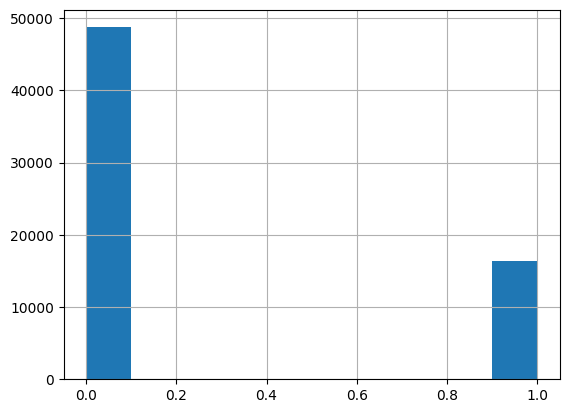

In [ ]:
df['CLASS'].hist()

In [ ]:
X=df.drop(columns=['CLASS'])
y=df['CLASS']

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_smote,y_smote=smote.fit_resample(X,y)

df_smote=pd.concat([pd.DataFrame(X_smote,columns=X.columns),
                    pd.Series(y_smote,name=y.name)],axis=1)


In [ ]:
df=df_smote

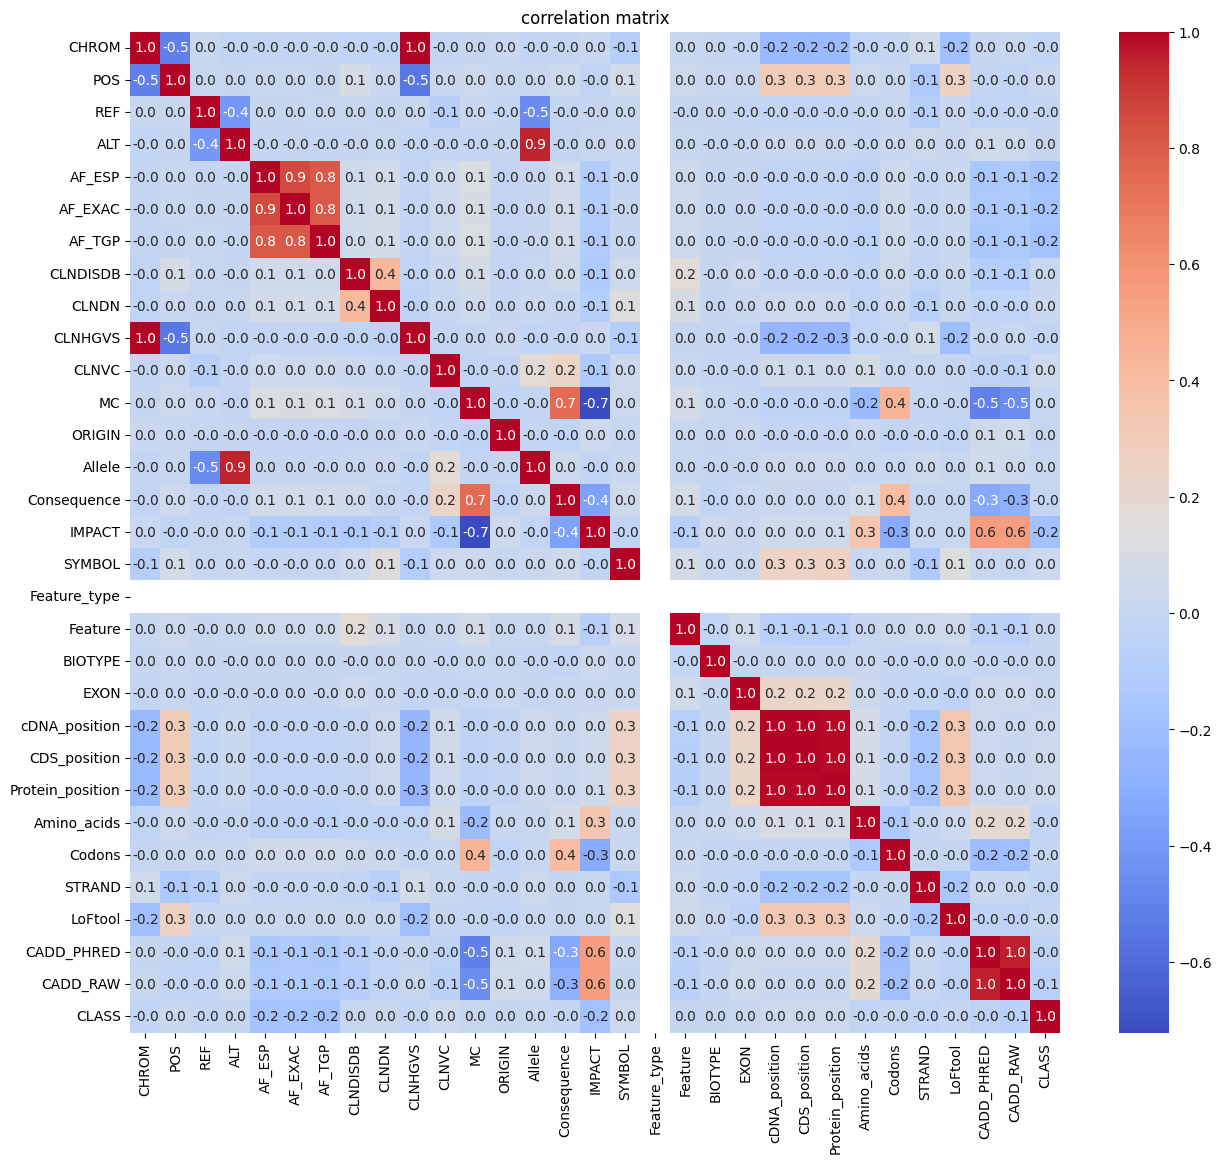

In [ ]:
plt.figure(figsize=(15,13))
corr_matix=df.corr()
sns.heatmap(corr_matix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [ ]:
df.drop(['Allele','AF_EXAC','AF_TGP'],axis=1,inplace=True)

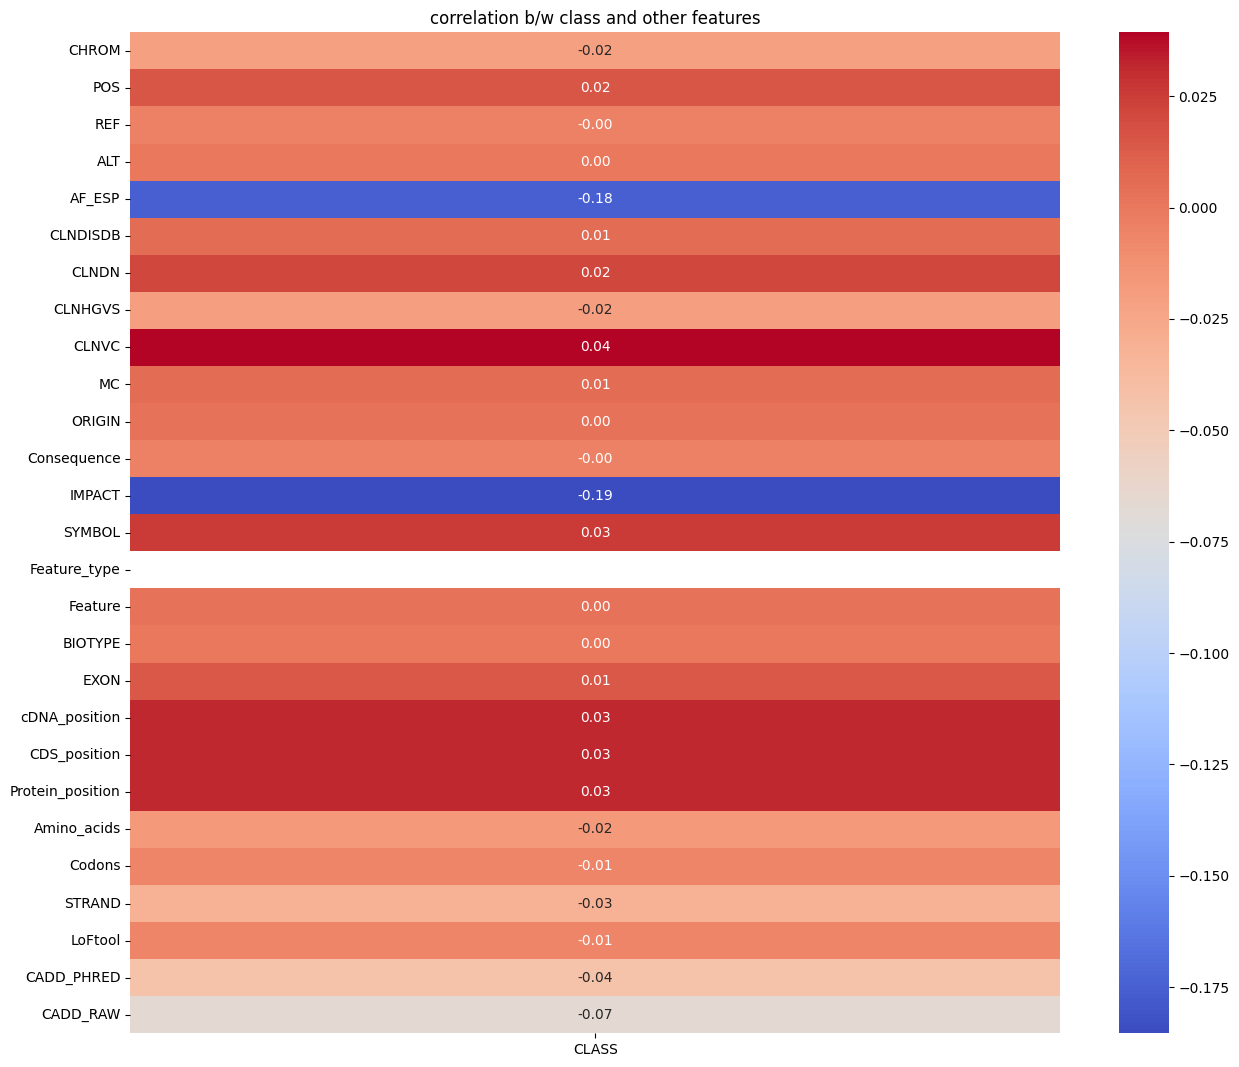

In [ ]:
plt.figure(figsize=(15,13))
class_corr=df.corr()['CLASS']
class_corr=class_corr.drop('CLASS')
sns.heatmap(class_corr.to_frame(),annot=True,fmt='0.2f',cmap='coolwarm',annot_kws={'size':10})
plt.title('correlation b/w class and other features')
plt.show()

In [ ]:
df.drop(['REF','ALT','ORIGIN','Consequence','Feature_type','Feature','BIOTYPE','CLNDISDB','MC',
         'EXON','Codons','LoFtool'],axis=1,inplace=True)

In [ ]:
df


,CHROM,POS,AF_ESP,CLNDN,CLNHGVS,CLNVC,IMPACT,SYMBOL,cDNA_position,CDS_position,Protein_position,Amino_acids,STRAND,CADD_PHRED,CADD_RAW,CLASS
0,1,1168180,0.077100,8947,326,6,2,200,552.000000,522.000000,174.000000,257,1.000000,1.053000,-0.208682,0
1,1,1470752,0.000000,8376,467,6,2,2135,523.000000,509.000000,170.000000,756,-1.000000,31.000000,6.517838,0
2,1,1737942,0.000000,8437,1179,6,2,892,632.000000,239.000000,80.000000,480,-1.000000,28.100000,6.061752,1
3,1,2160305,0.000000,8144,1826,6,2,1889,132.000000,100.000000,34.000000,377,1.000000,22.500000,3.114491,0
4,1,2160305,0.000000,8142,1827,6,2,1889,132.000000,100.000000,34.000000,362,1.000000,24.700000,4.766224,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97493,7,21639559,0.000130,1448,24022,6,2,581,2853.613877,2822.613877,941.526690,762,1.000000,25.424199,5.138565,1
97494,19,11222210,0.000000,2902,57606,6,2,1167,1268.776862,1081.776862,361.258954,287,1.000000,17.279306,2.136929,1
97495,10,42072757,0.000755,6117,34799,6,1,1055,1641.647284,1361.923231,453.913738,762,-0.272661,16.225318,1.985881,1
97496,8,100929770,0.001120,8251,29279,6,2,1324,1841.329167,1696.523797,566.041247,844,0.199889,30.279347,6.262733,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()

features=['CHROM','POS','AF_ESP','CLNDN','CLNHGVS','CLNVC','IMPACT','SYMBOL','cDNA_position','CDS_position','Protein_position',
          'Amino_acids','STRAND','CADD_PHRED','CADD_RAW']

scaled=scale.fit_transform(df[features])
df_scale=pd.DataFrame(scaled,columns=features)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x=df_scale
y=df['CLASS']

kf=KFold(n_splits=8,shuffle=True,random_state=42)

model=LogisticRegression()

best_accuracy=0
best_fold=-1

best_x_train=None
best_x_test=None
best_y_train=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]

  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_pred,y_test)
  print(f'Accuracy:{acc}')

  if acc>best_accuracy:
    best_accuracy=acc
    best_fold=fold
    best_x_train=x_train
    best_y_train=y_train
    best_x_test=x_test
    best_y_test=y_test
    best_y_pred=y_pred

print(f'\n best fold:{best_fold} with accuracy:{best_accuracy}')

Accuracy:0.6116672136527732
Accuracy:0.6141286511322612
Accuracy:0.6180356117174038
Accuracy:0.6085172725034873
Accuracy:0.6154098629687372
Accuracy:0.6268154590957578
Accuracy:0.6095019282842373
Accuracy:0.6125379502748831

 best fold:6 with accuracy:0.6268154590957578


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.774842044801838

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=252,
                             max_depth=30,
                             min_samples_split=5,
                             min_samples_leaf=1,
                             max_features='sqrt',
                             random_state=42)
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8361368671535242

In [ ]:
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential()
model.add(Dense(256,activation='relu',input_shape=(15,)))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(best_x_train,best_y_train,epochs=140,batch_size=32)

Epoch 1/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8165 - loss: 0.3728
Epoch 2/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8160 - loss: 0.3752
Epoch 3/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8173 - loss: 0.3708
Epoch 4/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8169 - loss: 0.3708
Epoch 5/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8186 - loss: 0.3688
Epoch 6/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8207 - loss: 0.3655
Epoch 7/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8191 - loss: 0.3681
Epoch 8/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8199 - loss: 0.3656
Epoch 9/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8209 - loss: 0.3658
Epoch 10/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8231 - loss: 0.3628
Epoch 11/140
2666/2666 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8239 - loss: 0.3611
Epoch 12/140
2666/

In [ ]:
y_pred=model.predict(best_x_test)
loss,accuracy=model.evaluate(best_x_test,best_y_test)
print(f'Accuracy:{accuracy}')

381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
381/381 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7222 - loss: 1.0170
Accuracy:0.7572823762893677


In [ ]:
import pickle
with open('clinvar conflicting ML Model.pkl',"wb") as file:
  pickle.dump(model,file)

In [ ]:
with open('/content/clinvar conflicting ML Model.pkl',"rb") as file:
  load_data=pickle.load(file)

# Conclusion
In this project, we developed a predictive model using both Machine Learning and Deep Learning techniques to classify genetic variants. K-Fold cross-validation was applied to ensure reliable and unbiased model evaluation. In Machine Learning, Decision Tree and Random Forest algorithms were implemented and compared based on accuracy. The results showed that the Random Forest model achieved higher accuracy and better performance compared to Decision Tree and Deep Learning models. Therefore, Random Forest was selected as the final model. The selected model was then saved in pickle format for future use and deployment. This system provides an efficient and accurate solution for automated genetic variant classification.